# Advertising Sales Prediction

## Business Scenario
A consumer goods company uses Television, Radio, and Newspaper advertising to promote its product. The goal is to understand how these advertising channels influence Sales and predict future sales from planned advertising budgets.

## Objectives
- Examine the Advertising dataset.
- Use TV, Radio, and Newspaper as input features.
- Use Sales as the target variable.
- Train a Multiple Linear Regression model.
- Predict sales for unseen data.
- Predict sales for TV = 150, Radio = 20, Newspaper = 30.
- Evaluate prediction error.
- Interpret model coefficients.
- Visualize actual vs predicted sales.
- Give one business recommendation and one technical improvement.


## 1. Import Libraries

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


## 2. Load Dataset

In [27]:
df = pd.read_csv("advertising.csv")
df.head()


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


## 3. Examine Dataset

In [28]:
print("Dataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData types:")
df.info()


Dataset shape: (200, 4)

Columns: ['TV', 'Radio', 'Newspaper', 'Sales']

Data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [29]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


### Check Missing Values

In [30]:
df.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

## 4. Variable Description

- **TV**: Advertising expenditure on television.
- **Radio**: Advertising expenditure on radio.
- **Newspaper**: Advertising expenditure on newspapers.
- **Sales**: Product sales.

TV, Radio, and Newspaper are the input features, while Sales is the target variable.


## 5. Exploratory Data Analysis

### Correlation Matrix

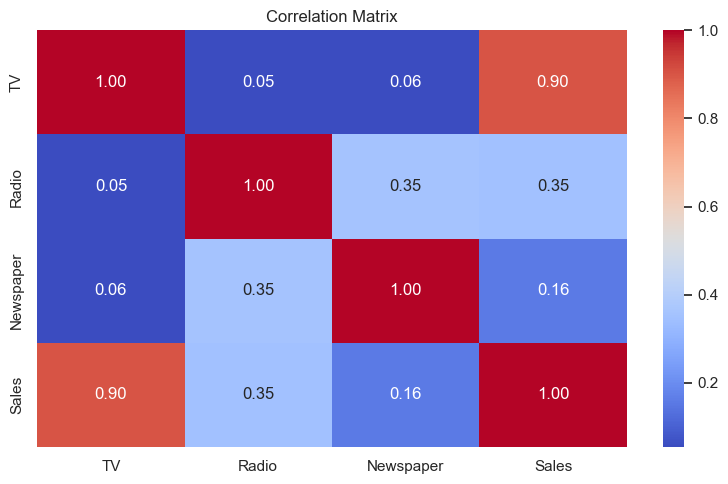

In [31]:
plt.figure(figsize=(8, 5))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


### Advertising Channels vs Sales

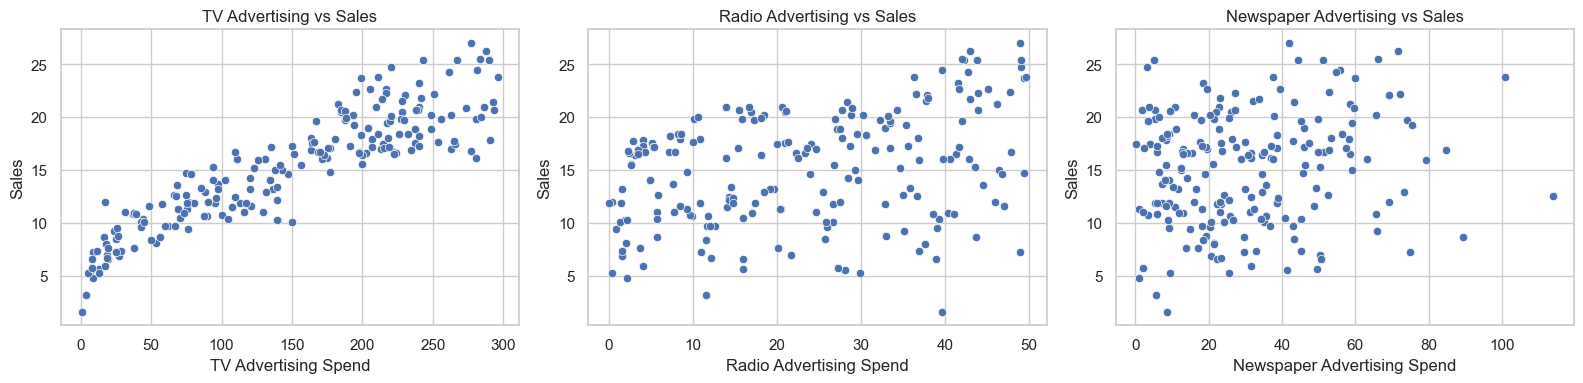

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, feature in zip(axes, ["TV", "Radio", "Newspaper"]):
    sns.scatterplot(data=df, x=feature, y="Sales", ax=ax)
    ax.set_title(f"{feature} Advertising vs Sales")
    ax.set_xlabel(f"{feature} Advertising Spend")
    ax.set_ylabel("Sales")

plt.tight_layout()
plt.show()


## 6. Define Features and Target

In [33]:
X = df[["TV", "Radio", "Newspaper"]]
y = df["Sales"]

print("Features:")
print(X.head())
print("\nTarget:")
print(y.head())


Features:
      TV  Radio  Newspaper
0  230.1   37.8       69.2
1   44.5   39.3       45.1
2   17.2   45.9       69.3
3  151.5   41.3       58.5
4  180.8   10.8       58.4

Target:
0    22.1
1    10.4
2    12.0
3    16.5
4    17.9
Name: Sales, dtype: float64


## 7. Train-Test Split

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)


Training data: (160, 3)
Testing data: (40, 3)


## 8. Build and Train Linear Regression Model

In [35]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully.")


Model trained successfully.


## 9. Predict Sales for Unseen Test Data

In [36]:
y_pred = model.predict(X_test)

comparison = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred
})

comparison.head(10)


,Actual Sales,Predicted Sales
0,16.9,17.034772
1,22.4,20.409740
2,21.4,23.723989
3,7.3,9.272785
4,24.7,21.682719
5,12.6,12.569402
6,22.3,21.081195
7,8.4,8.690350
8,16.5,17.237013
9,16.1,16.666575


## 10. Evaluate Model Prediction Error

In [37]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")


Mean Absolute Error (MAE): 1.2748
Mean Squared Error (MSE): 2.9078
Root Mean Squared Error (RMSE): 1.7052
R² Score: 0.9059


### Metric Interpretation

- **MAE**: Average absolute prediction error.
- **MSE**: Average squared prediction error.
- **RMSE**: Prediction error in the same units as Sales.
- **R²**: Proportion of variation in Sales explained by the model.

Higher R² and lower error values indicate better model performance.


## 11. Interpret Model Coefficients

In [38]:
print(f"Intercept: {model.intercept_:.4f}")

coefficients = pd.DataFrame({
    "Advertising Medium": X.columns,
    "Coefficient": model.coef_
})

coefficients


Intercept: 4.7141


,Advertising Medium,Coefficient
0,TV,0.054509
1,Radio,0.100945
2,Newspaper,0.004337


In [39]:
strongest_medium = coefficients.loc[
    coefficients["Coefficient"].abs().idxmax(), "Advertising Medium"
]
weakest_medium = coefficients.loc[
    coefficients["Coefficient"].abs().idxmin(), "Advertising Medium"
]

print("Strongest estimated impact:", strongest_medium)
print("Least estimated impact:", weakest_medium)


Strongest estimated impact: Radio
Least estimated impact: Newspaper


### Interpretation

The regression equation is:

**Sales = Intercept + (TV × TV coefficient) + (Radio × Radio coefficient) + (Newspaper × Newspaper coefficient)**

A positive coefficient indicates that, keeping the other variables constant, increasing that advertising spend is associated with an increase in predicted sales.

The medium with the largest coefficient has the strongest estimated impact in this model, while the smallest coefficient has the least estimated impact.


## 12. Predict Sales for Planned Advertising Budget

In [40]:
new_budget = pd.DataFrame({
    "TV": [150],
    "Radio": [20],
    "Newspaper": [30]
})

predicted_sales = model.predict(new_budget)[0]

print("Planned advertising budget:")
print(new_budget)
print(f"\nPredicted Sales: {predicted_sales:.4f}")


Planned advertising budget:
    TV  Radio  Newspaper
0  150     20         30

Predicted Sales: 15.0395


## 13. Actual Sales vs Predicted Sales

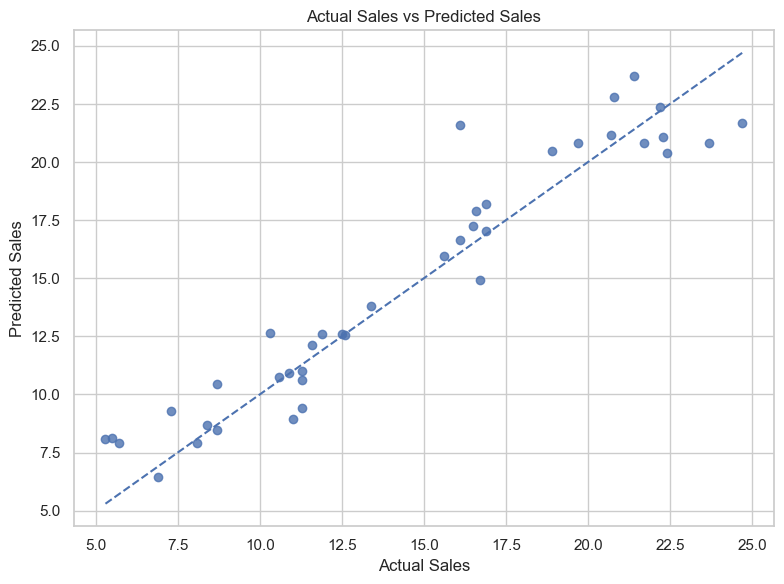

In [41]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.8)

min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual Sales vs Predicted Sales")
plt.tight_layout()
plt.show()


Points closer to the diagonal reference line represent more accurate predictions.

## 14. Actual vs Predicted Sales — Line Plot

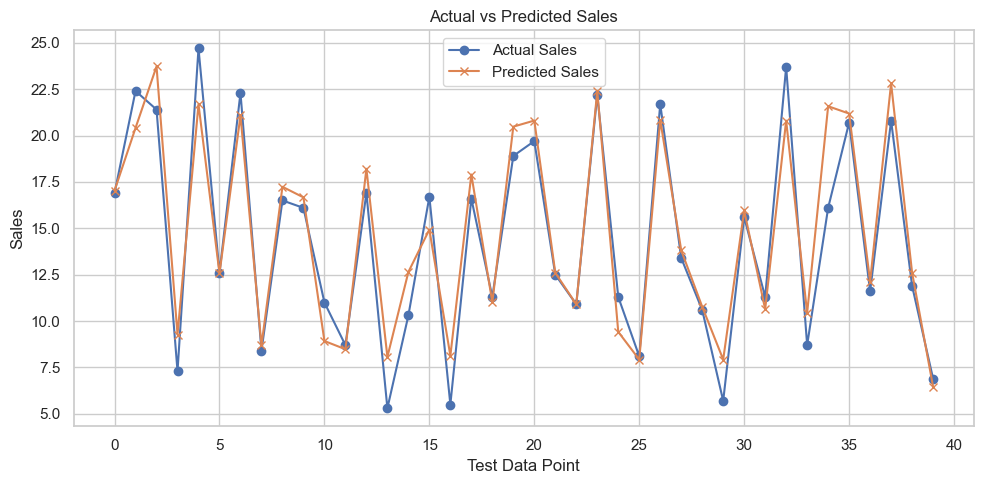

In [42]:
plt.figure(figsize=(10, 5))

plt.plot(y_test.values, marker="o", label="Actual Sales")
plt.plot(y_pred, marker="x", label="Predicted Sales")

plt.xlabel("Test Data Point")
plt.ylabel("Sales")
plt.title("Actual vs Predicted Sales")
plt.legend()
plt.tight_layout()
plt.show()


## 15. Coefficient Visualization

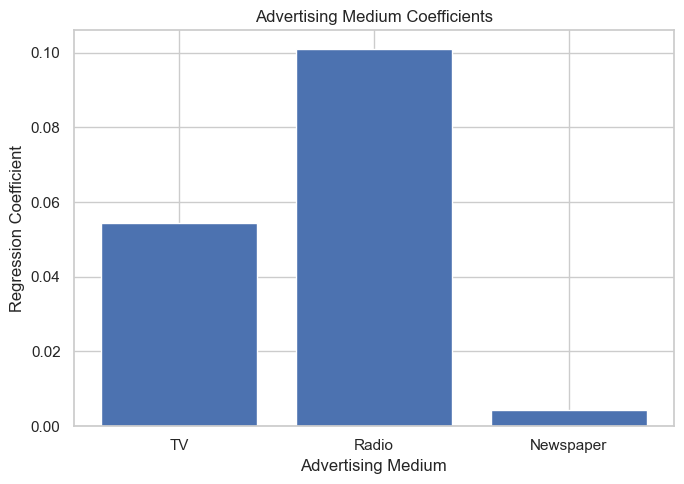

In [43]:
plt.figure(figsize=(7, 5))
plt.bar(coefficients["Advertising Medium"], coefficients["Coefficient"])
plt.xlabel("Advertising Medium")
plt.ylabel("Regression Coefficient")
plt.title("Advertising Medium Coefficients")
plt.tight_layout()
plt.show()


## 16. Business Recommendation

The company should prioritize **Radio advertising** and maintain strong investment in **TV advertising**, because the regression model indicates stronger estimated positive impacts for these channels. The company can consider reallocating part of the Newspaper advertising budget toward higher-performing channels while monitoring actual sales and campaign ROI.

Newspaper advertising should not be eliminated solely from this model because business decisions should also consider cost, audience reach, brand objectives, and other factors.


## 17. Technical Improvement

Prediction accuracy can be improved by using **cross-validation** and comparing Linear Regression with nonlinear models such as **Random Forest Regression** or **Gradient Boosting**. Hyperparameter tuning can then be used to select the best-performing model.


## 18. Conclusion

The analysis demonstrates how TV, Radio, and Newspaper advertising expenditure can be used to predict product Sales.

A Multiple Linear Regression model was trained using historical advertising data and evaluated using MAE, MSE, RMSE, and R². The coefficient analysis identifies which advertising medium has the strongest and weakest estimated impact on sales.

The model was also used to predict sales for a planned budget of TV = 150, Radio = 20, and Newspaper = 30.

Overall, the results can help the company make more data-driven advertising allocation decisions. Future work can improve the model through cross-validation, feature engineering, and comparison with advanced regression algorithms.


## 19. Final Results Summary

In [44]:
print("========== FINAL RESULTS ==========")
print(f"Dataset shape: {df.shape}")
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"Strongest medium: {strongest_medium}")
print(f"Weakest medium: {weakest_medium}")
print(f"Predicted Sales for TV=150, Radio=20, Newspaper=30: {predicted_sales:.4f}")
print("===================================")


========== FINAL RESULTS ==========
Dataset shape: (200, 4)
MAE: 1.2748
MSE: 2.9078
RMSE: 1.7052
R² Score: 0.9059
Strongest medium: Radio
Weakest medium: Newspaper
Predicted Sales for TV=150, Radio=20, Newspaper=30: 15.0395


## Final Summary

The Advertising dataset was analyzed to understand how TV, Radio, and Newspaper advertising expenditures influence product sales. A Multiple Linear Regression model was built using TV, Radio, and Newspaper as input features and Sales as the target variable.

The model achieved a **Mean Absolute Error (MAE) of 1.2748**, **Root Mean Squared Error (RMSE) of 1.7052**, and an **R² score of 0.9059**. This means the model explains approximately **90.59% of the variation in sales**, indicating a good predictive performance.

Based on the model coefficients, **Radio advertising has the strongest estimated impact on sales**, while **Newspaper advertising has the least impact** among the three channels.

For the planned advertising budget of **TV = 150, Radio = 20, and Newspaper = 30**, the model predicts approximately **15.04 units of sales**.

### Business Recommendation
The company should prioritize **Radio and TV advertising**, as they show stronger estimated relationships with sales. The company can consider reviewing the Newspaper advertising budget and reallocating some spending toward better-performing channels while monitoring actual sales and return on investment.

### Technical Improvement
Prediction accuracy can be improved by applying **cross-validation** and comparing Linear Regression with other machine-learning models such as **Random Forest Regression or Gradient Boosting**. Hyperparameter tuning can also be performed to identify the best-performing model.

Overall, the analysis provides useful insights for making **data-driven advertising and sales decisions**.